# 🤖 F1 2026 Australian GP — Feature Engineering & ML Prediction
## Notebook 02

**Pipeline:**
1. Setup & Config
2. Load Raw Data
3. Feature Engineering
4. Feature Analysis
5. Model Training (LOO-CV)
6. Model Comparison
7. Feature Importance
8. Actual vs Predicted
9. Summary & Export

> ⚠️ **Lưu ý:** Notebook này load thẳng từ raw CSV — không cần chạy Notebook 01 trước.  
> Tất cả hình ảnh lưu vào `./figures_ml/`


## 1. 📦 Setup & Config

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, ast, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics         import mean_absolute_error, r2_score
from scipy.stats             import spearmanr

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('⚠️  XGBoost not installed — pip install xgboost')

# ── Output folder ─────────────────────────────────────────────
FIG_DIR = './figures_ml'
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    path = f'{FIG_DIR}/{name}'
    plt.savefig(path, dpi=130, bbox_inches='tight', facecolor='#0f0f0f')
    print(f'  💾 {path}')

# ── Style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#2e2e2e', 'axes.labelcolor':  '#cccccc',
    'xtick.color':      '#888888', 'ytick.color':      '#888888',
    'text.color':       '#dddddd', 'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',      'font.family':      'monospace',
    'axes.titlesize':   12,        'axes.labelsize':   10,
    'figure.dpi':       120,
})

TEAM_COLORS = {
    'Mercedes':'#00D7B6',      'Ferrari':'#E8002D',
    'McLaren':'#FF8000',       'Red Bull Racing':'#3671C6',
    'Aston Martin':'#229971',  'Alpine':'#FF87BC',
    'Williams':'#64C4FF',      'Haas F1 Team':'#B6BABD',
    'Audi':'#52E252',          'Racing Bulls':'#6692FF',
    'Cadillac':'#C8AA6E',
}
EXCLUDE = ['SAI', 'STR']

print(f'✅ Setup done | XGBoost: {HAS_XGB}')
print(f'   Figures → {FIG_DIR}/')


✅ Setup done | XGBoost: True
   Figures → ./figures_ml/


## 2. 📂 Load Raw Data

In [17]:
DATA_DIR = '../AustralianGrandPrix'   # ← đổi nếu cần

fp1       = pd.read_csv(f'{DATA_DIR}/fp1_practice_1_fastest.csv', index_col=0)
fp2       = pd.read_csv(f'{DATA_DIR}/fp2_practice_2_fastest.csv', index_col=0)
fp3       = pd.read_csv(f'{DATA_DIR}/fp3_practice_3_fastest.csv', index_col=0)
quali     = pd.read_csv(f'{DATA_DIR}/q_qualifying_fastest.csv',   index_col=0)
race      = pd.read_csv(f'{DATA_DIR}/r_race_results.csv')
race_pit  = pd.read_csv(f'{DATA_DIR}/r_race_pitstops.csv')

# ── Filter EXCLUDE ────────────────────────────────────────────
for df in [fp1, fp2, fp3, quali]:
    df.drop(df[df['Driver'].isin(EXCLUDE)].index, inplace=True)
    df.reset_index(drop=True, inplace=True)

# ── Chuẩn hóa tên cột Gap ─────────────────────────────────────
for df in [fp1, fp2, fp3]:
    if 'Gap_to_P1_s' in df.columns:
        df.rename(columns={'Gap_to_P1_s': 'Gap_s'}, inplace=True)
if 'Gap_to_Pole_s' in quali.columns:
    quali.rename(columns={'Gap_to_Pole_s': 'Gap_s'}, inplace=True)

# ── Race results ──────────────────────────────────────────────
race_clean = race[['Abbreviation','TeamName','Position',
                   'GridPosition','Status','Points']].copy()
race_clean.columns = ['Driver','Team','race_pos','grid_pos','status','points']
race_clean = race_clean[~race_clean['Driver'].isin(EXCLUDE)].copy()
race_clean['race_pos']  = pd.to_numeric(race_clean['race_pos'],  errors='coerce')
race_clean['grid_pos']  = pd.to_numeric(race_clean['grid_pos'],  errors='coerce')
race_clean['points']    = pd.to_numeric(race_clean['points'],    errors='coerce')
race_clean['dnf']       = race_clean['status'].isin(['Retired','Did not start'])

# GridPosition map — dùng để fix NaN sau này
GRID_MAP = dict(zip(race_clean['Driver'], race_clean['grid_pos']))

# Driver → team/color maps
driver_team  = dict(zip(race_clean['Driver'], race_clean['Team']))
driver_color = {d: TEAM_COLORS.get(t,'#888888') for d,t in driver_team.items()}

# ── Pit stops ─────────────────────────────────────────────────
race_pit.columns = ['Driver','pit_stops','pit_laps_raw']

print(f'✅ Data loaded — {len(fp3)} drivers')
print(f'   Race results: {len(race_clean)} | Pit stops: {len(race_pit)}')


✅ Data loaded — 20 drivers
   Race results: 20 | Pit stops: 19


## 3. ⚙️ Feature Engineering

**RULE:** Chỉ dùng features có **trước race** (pre-race only).  
Không dùng: `pit_stops`, `race_laps`, `positions_gained` (chỉ biết sau race).

| Group | Features |
|---|---|
| FP3 pace | laptime, gap, s1/s2/s3, topspeed |
| Qualifying | laptime, gap, s1/s2/s3, topspeed |
| Engineered | fp_improvement, fp2_to_fp3, quali_vs_fp3, sector_consistency, theoretical_best, speed_diff |
| Starting | grid_position |


In [18]:
# ── Base features ────────────────────────────────────────────
fp1_m = fp1[['Driver','LapTime_s']].rename(columns={'LapTime_s':'fp1_laptime'})
fp2_m = fp2[['Driver','LapTime_s']].rename(columns={'LapTime_s':'fp2_laptime'})

fp3_m = fp3[['Driver','LapTime_s','Sector1Time_s','Sector2Time_s',
             'Sector3Time_s','SpeedFL','Gap_s']].copy()
fp3_m.columns = ['Driver','fp3_laptime','fp3_s1','fp3_s2','fp3_s3',
                 'fp3_topspeed','fp3_gap']

q_m = quali[['Driver','LapTime_s','Sector1Time_s','Sector2Time_s',
             'Sector3Time_s','SpeedFL','Gap_s']].copy()
q_m.columns = ['Driver','quali_laptime','quali_s1','quali_s2','quali_s3',
               'quali_topspeed','quali_gap']

# Grid từ race results (GRID_MAP) — không lấy từ quali_res vì toàn NaN
grid_m  = pd.DataFrame({'Driver': list(GRID_MAP.keys()),
                        'grid_position': list(GRID_MAP.values())})
target  = race_clean[['Driver','race_pos','status','points','dnf']]

# ── Merge ─────────────────────────────────────────────────────
df = (fp1_m
      .merge(fp2_m,   on='Driver', how='outer')
      .merge(fp3_m,   on='Driver', how='left')
      .merge(q_m,     on='Driver', how='left')
      .merge(grid_m,  on='Driver', how='left')
      .merge(target,  on='Driver', how='left')
     )
df['Team'] = df['Driver'].map(driver_team)

# ── Engineered features ───────────────────────────────────────
df['fp_improvement']      = df['fp1_laptime'] - df['fp3_laptime']
df['fp2_to_fp3']          = df['fp2_laptime'] - df['fp3_laptime']
df['quali_vs_fp3']        = df['quali_laptime'] - df['fp3_laptime']
df['sector_consistency']  = df[['fp3_s1','fp3_s2','fp3_s3']].std(axis=1)
df['fp3_theoretical_best']= df['fp3_s1'] + df['fp3_s2'] + df['fp3_s3']
df['speed_diff']          = df['quali_topspeed'] - df['fp3_topspeed']
df['best_sector']         = df[['fp3_s1','fp3_s2','fp3_s3']].min(axis=1)

# ── Fix NaN: ALO không có FP1 ────────────────────────────────
for col in ['fp_improvement','fp2_to_fp3']:
    df[col] = df[col].fillna(df[col].median())

# ── VER qualifying anomaly: đánh dấu + penalty ───────────────
df['quali_anomaly'] = df['Driver'] == 'VER'
# Giữ nguyên quali_gap thật của VER để model thấy penalty tự nhiên
# (VER quali_gap = 102s - rất lớn, model sẽ tự học)

df.reset_index(drop=True, inplace=True)

print(f'✅ Feature table: {df.shape[0]} drivers × {df.shape[1]} cols')
print()
print('Null check:')
null_check = df.isnull().sum()
null_check = null_check[null_check > 0]
if len(null_check):
    for col, cnt in null_check.items():
        print(f'  {col}: {cnt}')
else:
    print('  Không có NaN ✅')
print()
print(df[['Driver','Team','fp3_gap','quali_gap','grid_position',
          'race_pos','status']].to_string(index=False))


✅ Feature table: 20 drivers × 29 cols

Null check:
  fp1_laptime: 1

Driver            Team  fp3_gap  quali_gap  grid_position  race_pos        status
   ALB        Williams    2.611      2.423           15.0      12.0        Lapped
   ALO    Aston Martin    3.667      3.451           17.0      18.0       Retired
   ANT        Mercedes    1.271      0.293            2.0       2.0      Finished
   BEA    Haas F1 Team    1.725      1.793           12.0       7.0        Lapped
   BOR            Audi    1.406      1.703           10.0       9.0        Lapped
   BOT        Cadillac    4.461      4.726           19.0      19.0       Retired
   COL          Alpine    2.360      2.682           16.0      14.0        Lapped
   GAS          Alpine    2.018      1.983           14.0      10.0        Lapped
   HAD Red Bull Racing    1.084      0.785            3.0      20.0       Retired
   HAM         Ferrari    0.616      0.960            7.0       4.0      Finished
   HUL            Audi    2.0

## 4. 🔍 Feature Analysis

  💾 ./figures_ml/01_feature_correlation.png


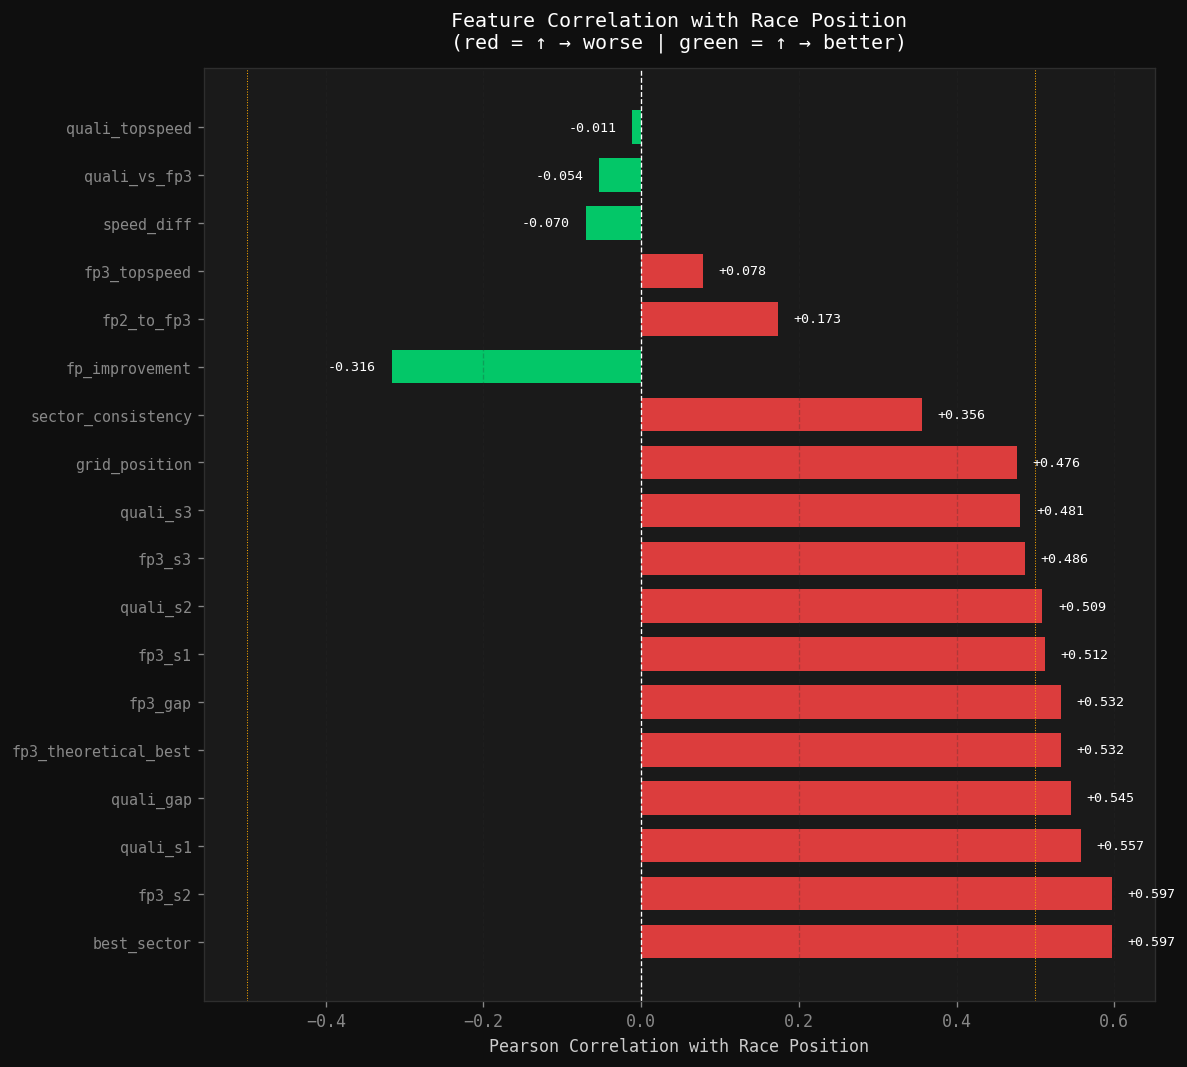

Top 10 features:
  best_sector                   : +0.597  ██████████████
  fp3_s2                        : +0.597  ██████████████
  quali_s1                      : +0.557  █████████████
  quali_gap                     : +0.545  █████████████
  fp3_theoretical_best          : +0.532  █████████████
  fp3_gap                       : +0.532  █████████████
  fp3_s1                        : +0.512  ████████████
  quali_s2                      : +0.509  ████████████
  fp3_s3                        : +0.486  ████████████
  quali_s3                      : +0.481  ████████████


In [19]:
# ── 4.1 Correlation với race_pos ─────────────────────────────
FEATURE_COLS = [
    'fp3_gap', 'fp3_s1', 'fp3_s2', 'fp3_s3',
    'fp3_topspeed', 'fp3_theoretical_best',
    'quali_gap', 'quali_s1', 'quali_s2', 'quali_s3', 'quali_topspeed',
    'grid_position',
    'fp_improvement', 'fp2_to_fp3', 'quali_vs_fp3',
    'sector_consistency', 'speed_diff', 'best_sector',
]
TARGET_COL = 'race_pos'

# Exclude VER anomaly + fillna median cho corr
corr_data = df[~df['quali_anomaly']][FEATURE_COLS + [TARGET_COL]].copy()
corr_data = corr_data.fillna(corr_data.median(numeric_only=True))
corr_series = corr_data.corrwith(corr_data[TARGET_COL]).drop(TARGET_COL)
corr_series = corr_series.dropna().sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
fig.patch.set_facecolor('#0f0f0f')
colors = ['#ff4444' if v>0 else '#00e676' for v in corr_series.values]
ax.barh(range(len(corr_series)), corr_series.values, color=colors, alpha=0.85, height=0.7)
ax.set_yticks(range(len(corr_series)))
ax.set_yticklabels(corr_series.index, fontsize=9)
ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax.axvline( 0.5, color='#ffaa00', linewidth=0.6, linestyle=':')
ax.axvline(-0.5, color='#ffaa00', linewidth=0.6, linestyle=':')
for i, (feat, val) in enumerate(corr_series.items()):
    ax.text(val+(0.02 if val>=0 else -0.02), i, f'{val:+.3f}',
            va='center', ha='left' if val>=0 else 'right', fontsize=8, color='white')
ax.set_xlabel('Pearson Correlation with Race Position')
ax.set_title('Feature Correlation with Race Position\n'
             '(red = ↑ → worse | green = ↑ → better)',
             color='white', pad=12)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout(); savefig('01_feature_correlation.png'); plt.show()

print('Top 10 features:')
for feat, val in corr_series.head(10).items():
    bar = '█' * int(abs(val)*25)
    print(f'  {feat:30s}: {val:+.3f}  {bar}')


  💾 ./figures_ml/02_feature_distributions.png


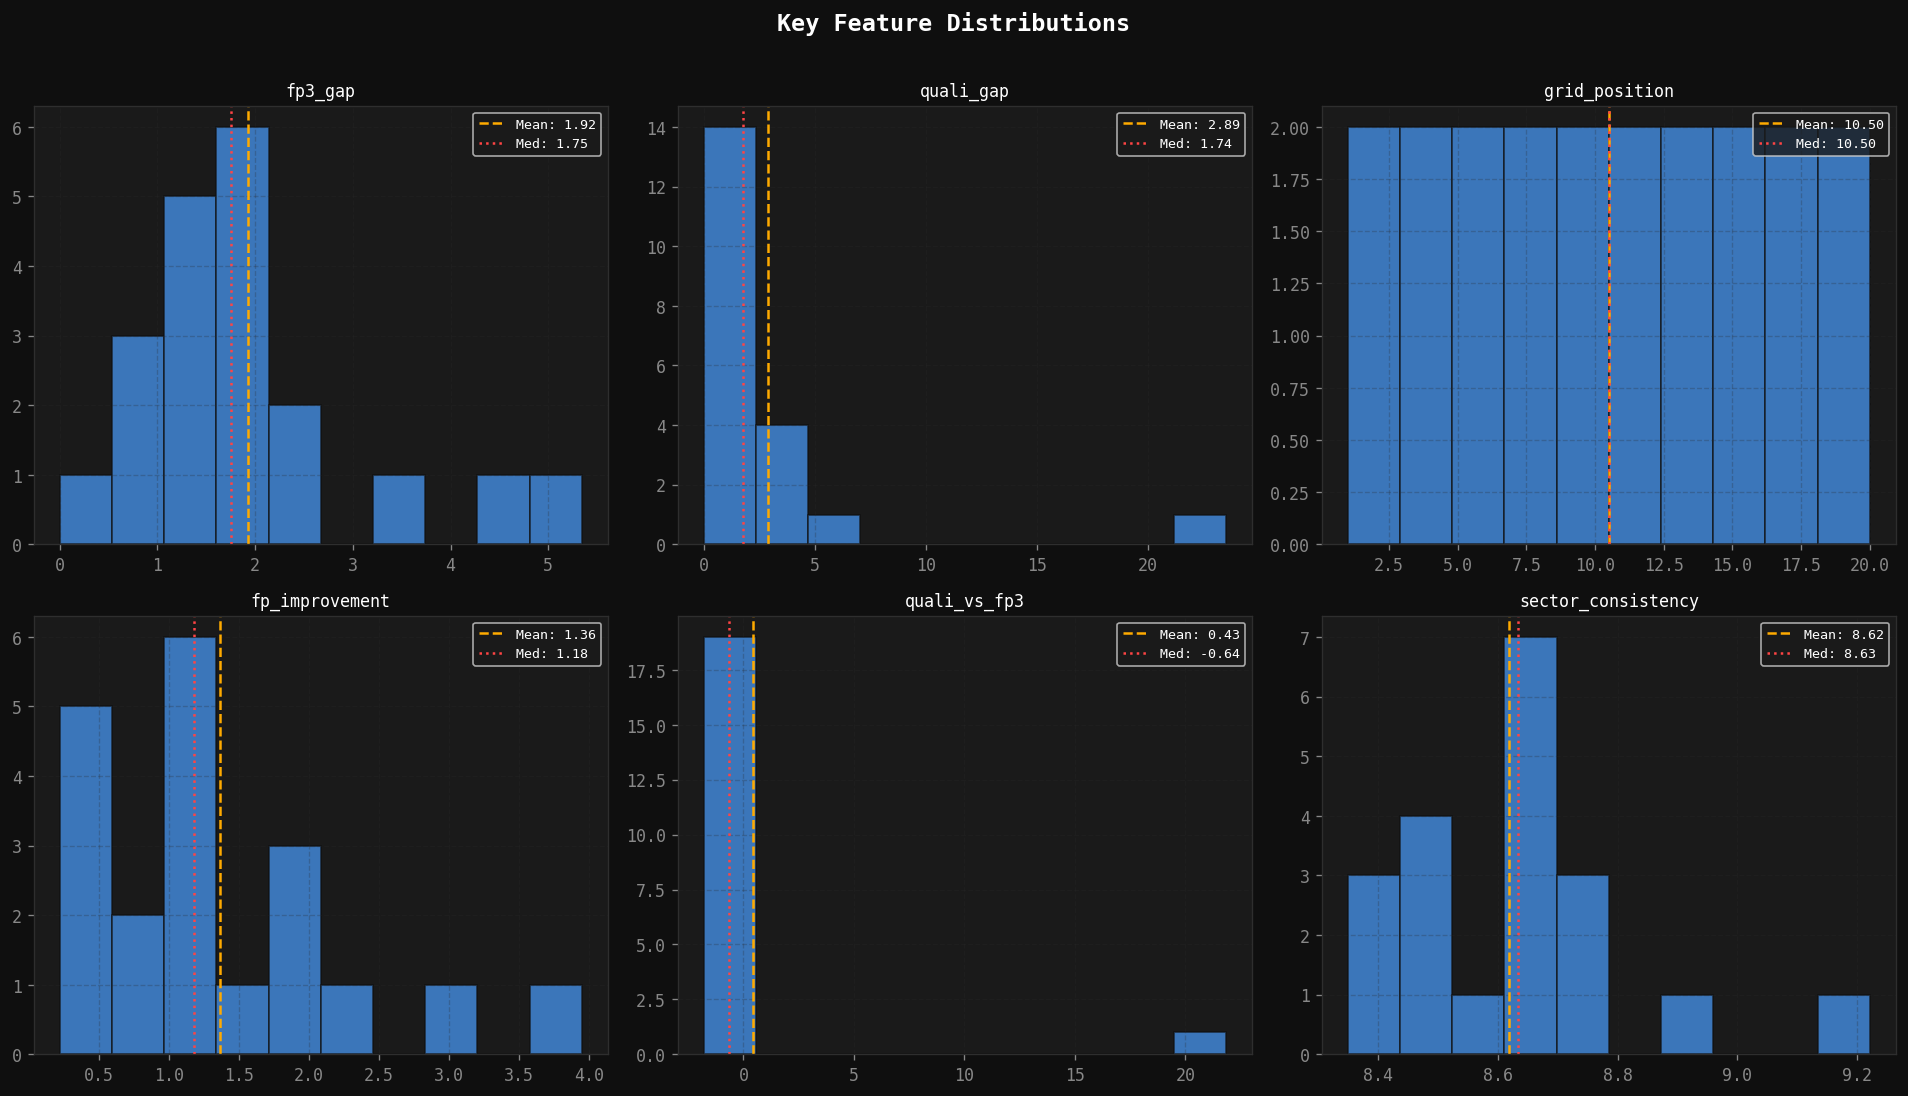

In [20]:
# ── 4.2 Feature distribution (key features) ──────────────────
key_feats = ['fp3_gap','quali_gap','grid_position','fp_improvement',
             'quali_vs_fp3','sector_consistency']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.flatten()

for ax, feat in zip(axes, key_feats):
    data = df[feat].dropna()
    ax.hist(data, bins=10, color='#4a9eff', alpha=0.7, edgecolor='#0f0f0f')
    ax.axvline(data.mean(),   color='#ffaa00', linewidth=1.5, linestyle='--',
               label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='#ff4444', linewidth=1.5, linestyle=':',
               label=f'Med: {data.median():.2f}')
    ax.set_title(feat, color='white', fontsize=10)
    ax.legend(fontsize=8, facecolor='#1a1a1a', labelcolor='white')
    ax.grid(alpha=0.25)

plt.suptitle('Key Feature Distributions', color='white', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout(); savefig('02_feature_distributions.png'); plt.show()


  💾 ./figures_ml/03_top_features_scatter.png


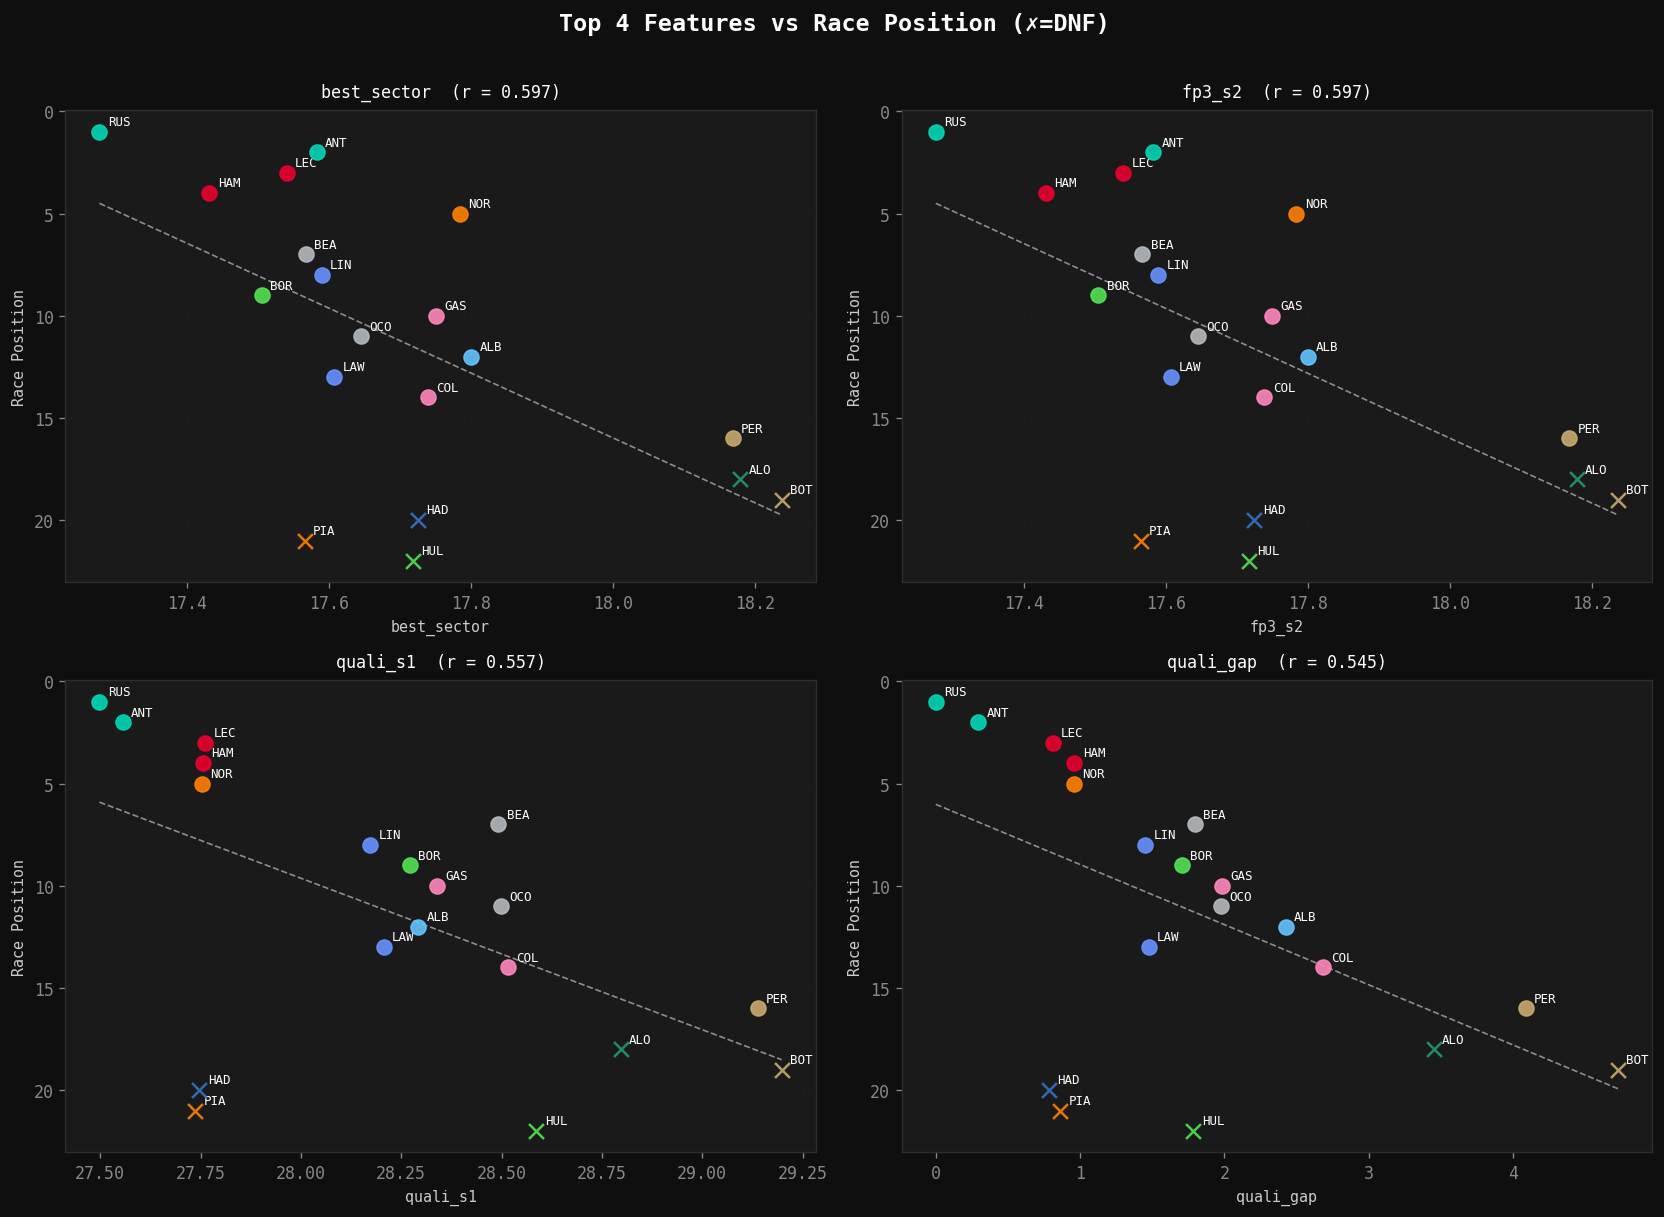

In [21]:
# ── 4.3 Top 4 features scatter vs race_pos ───────────────────
top4 = corr_series.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.flatten()

plot_data = df[~df['quali_anomaly']].dropna(subset=[TARGET_COL]).copy()

for ax, feat in zip(axes, top4):
    valid = plot_data.dropna(subset=[feat, TARGET_COL])
    for _, row in valid.iterrows():
        c = TEAM_COLORS.get(row['Team'],'#888888')
        m = 'x' if row['dnf'] else 'o'
        ax.scatter(row[feat], row[TARGET_COL], color=c, s=80, marker=m, alpha=0.9, zorder=5)
        ax.annotate(row['Driver'], (row[feat], row[TARGET_COL]),
                    textcoords='offset points', xytext=(5,4), fontsize=7.5, color='white')
    if len(valid)>2:
        z = np.polyfit(valid[feat], valid[TARGET_COL], 1)
        xl = np.linspace(valid[feat].min(), valid[feat].max(), 100)
        ax.plot(xl, np.poly1d(z)(xl), '--', color='white', linewidth=1, alpha=0.5)
        r = valid[[feat, TARGET_COL]].corr().iloc[0,1]
        ax.set_title(f'{feat}  (r = {r:.3f})', color='white', fontsize=10, pad=8)
    ax.set_xlabel(feat, fontsize=9); ax.set_ylabel('Race Position', fontsize=9)
    ax.invert_yaxis(); ax.grid(alpha=0.2)

plt.suptitle('Top 4 Features vs Race Position (✗=DNF)',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); savefig('03_top_features_scatter.png'); plt.show()


## 5. 🤖 Model Training — LOO-CV

**Leave-One-Out Cross Validation** phù hợp với dataset nhỏ (20 drivers).  
Mỗi fold: train 19 drivers, predict 1 driver còn lại → lặp 20 lần.


In [22]:
# ── Chọn feature set cuối ────────────────────────────────────
MODEL_FEATURES = [
    'fp3_gap', 'fp3_s1', 'fp3_s2', 'fp3_s3',
    'fp3_topspeed', 'fp3_theoretical_best',
    'quali_gap', 'quali_topspeed',
    'grid_position',
    'fp_improvement', 'fp2_to_fp3', 'quali_vs_fp3',
    'sector_consistency', 'speed_diff',
]

# Dataset: giữ VER (quali_gap lớn = penalty tự nhiên)
df_ml = df.dropna(subset=MODEL_FEATURES + [TARGET_COL]).reset_index(drop=True)
df_ml[TARGET_COL] = df_ml[TARGET_COL].astype(int)

X = df_ml[MODEL_FEATURES].copy()
y = df_ml[TARGET_COL].copy()

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f'✅ ML dataset: {X.shape[0]} drivers × {X.shape[1]} features')
print(f'   Target: P{y.min()} – P{y.max()}')
print()
print(df_ml[['Driver','Team','grid_position','race_pos','status']].to_string(index=False))


✅ ML dataset: 20 drivers × 14 features
   Target: P1 – P22

Driver            Team  grid_position  race_pos        status
   ALB        Williams           15.0        12        Lapped
   ALO    Aston Martin           17.0        18       Retired
   ANT        Mercedes            2.0         2      Finished
   BEA    Haas F1 Team           12.0         7        Lapped
   BOR            Audi           10.0         9        Lapped
   BOT        Cadillac           19.0        19       Retired
   COL          Alpine           16.0        14        Lapped
   GAS          Alpine           14.0        10        Lapped
   HAD Red Bull Racing            3.0        20       Retired
   HAM         Ferrari            7.0         4      Finished
   HUL            Audi           11.0        22 Did not start
   LAW    Racing Bulls            8.0        13        Lapped
   LEC         Ferrari            4.0         3      Finished
   LIN    Racing Bulls            9.0         8        Lapped
   NOR    

In [23]:
# ── LOO-CV Training ───────────────────────────────────────────
loo = LeaveOneOut()

models = {
    'Linear Regression' : LinearRegression(),
    'Ridge (α=1)'       : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(
                            n_estimators=200, max_depth=4,
                            min_samples_leaf=2, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(
                            n_estimators=100, max_depth=3,
                            learning_rate=0.1, random_state=42),
}
if HAS_XGB:
    models['XGBoost'] = XGBRegressor(
        n_estimators=100, max_depth=3,
        learning_rate=0.1, random_state=42, verbosity=0)

results      = {}
all_preds    = {}

print('Training with LOO-CV...\n')

for name, model in models.items():
    oof = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X_scaled):
        model.fit(X_scaled.iloc[train_idx], y.iloc[train_idx])
        oof[test_idx] = model.predict(X_scaled.iloc[test_idx])

    mae     = mean_absolute_error(y, oof)
    r2      = r2_score(y, oof)
    spear,p = spearmanr(y, oof)
    w2      = np.mean(np.abs(y - oof) <= 2)
    w3      = np.mean(np.abs(y - oof) <= 3)

    results[name]   = {
        'MAE'      : round(mae,   3),
        'R²'       : round(r2,    3),
        'Spearman' : round(spear, 3),
        'p-value'  : round(p,     4),
        'Within±2' : f'{w2:.0%}',
        'Within±3' : f'{w3:.0%}',
    }
    all_preds[name] = oof.copy()
    print(f'  {name:22s} | MAE={mae:.2f} | R²={r2:.3f} | '
          f'Spearman={spear:.3f} | ±2={w2:.0%} | ±3={w3:.0%}')

# Retrain full để lấy feature importance
for name, model in models.items():
    model.fit(X_scaled, y)

best_name = pd.DataFrame(results).T['Spearman'].astype(float).idxmax()
print(f'\n✅ Done! Best model (Spearman): {best_name}')


Training with LOO-CV...

  Linear Regression      | MAE=13.44 | R²=-13.872 | Spearman=0.132 | ±2=10% | ±3=15%
  Ridge (α=1)            | MAE=5.77 | R²=-0.207 | Spearman=0.195 | ±2=15% | ±3=40%
  Random Forest          | MAE=5.84 | R²=-0.257 | Spearman=0.287 | ±2=20% | ±3=25%
  Gradient Boosting      | MAE=7.58 | R²=-0.996 | Spearman=-0.271 | ±2=10% | ±3=15%
  XGBoost                | MAE=7.39 | R²=-0.778 | Spearman=-0.104 | ±2=5% | ±3=10%

✅ Done! Best model (Spearman): Random Forest


## 6. 📊 Model Comparison

MODEL COMPARISON (LOO-CV):
                      MAE      R² Spearman p-value Within±2 Within±3
Linear Regression  13.443 -13.872    0.132  0.5781      10%      15%
Ridge (α=1)         5.766  -0.207    0.195  0.4088      15%      40%
Random Forest        5.84  -0.257    0.287  0.2195      20%      25%
Gradient Boosting   7.584  -0.996   -0.271  0.2484      10%      15%
XGBoost             7.393  -0.778   -0.104  0.6633       5%      10%
  💾 ./figures_ml/04_model_comparison.png


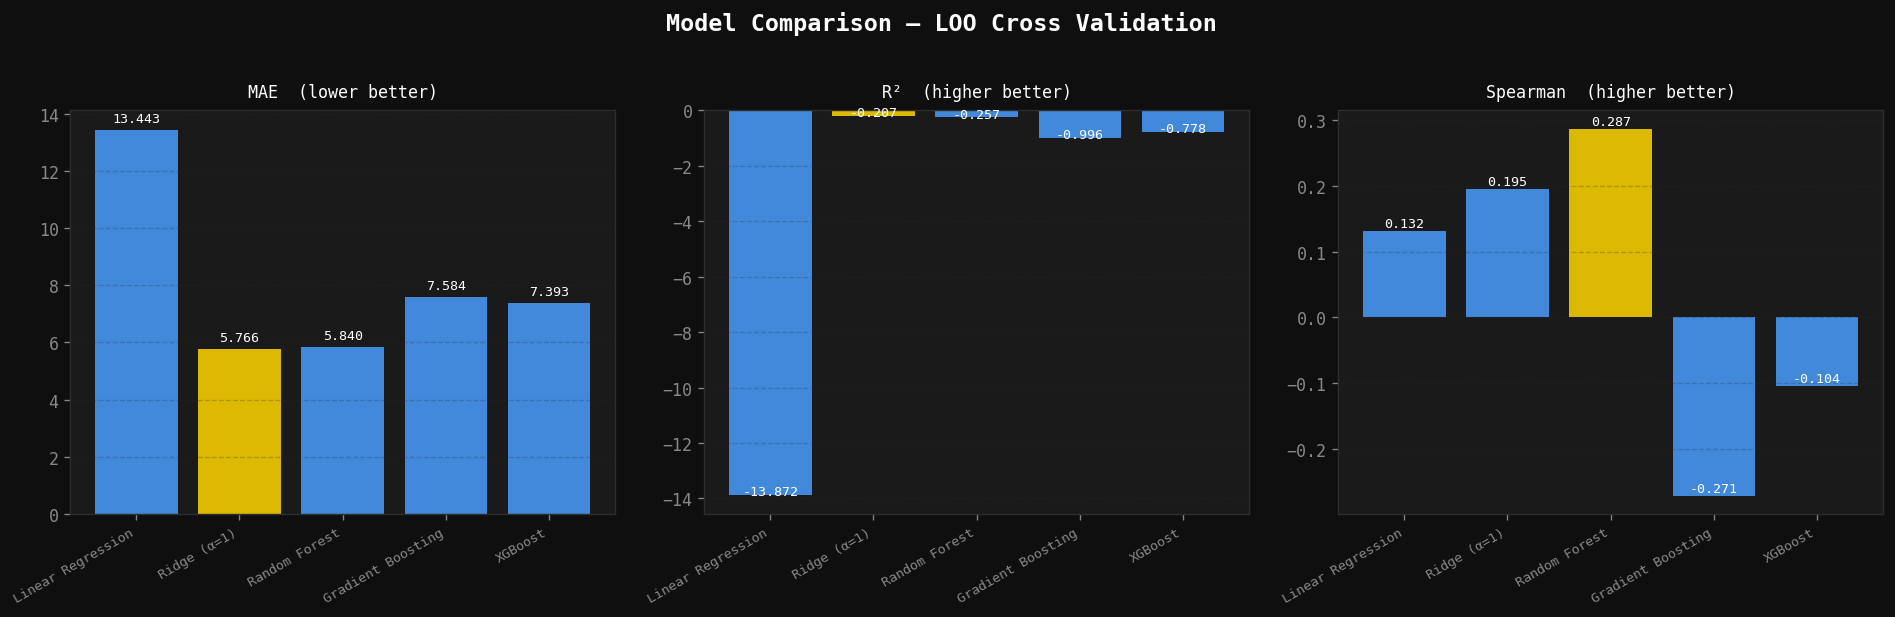

In [24]:
results_df = pd.DataFrame(results).T
print('MODEL COMPARISON (LOO-CV):')
print(results_df.to_string())

# ── Visual ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f0f0f')

metrics = [
    ('MAE',      True,  'lower better'),
    ('R²',       False, 'higher better'),
    ('Spearman', False, 'higher better'),
]

for ax, (metric, lower_better, note) in zip(axes, metrics):
    vals = results_df[metric].astype(float)
    best_idx = vals.idxmin() if lower_better else vals.idxmax()
    colors = ['#ffd700' if m==best_idx else '#4a9eff' for m in vals.index]
    ax.bar(range(len(vals)), vals.values, color=colors, alpha=0.85)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'{metric}  ({note})', color='white', fontsize=10, pad=8)
    ax.grid(axis='y', alpha=0.25)
    for i, v in enumerate(vals.values):
        ax.text(i, v+max(vals)*0.02, f'{v:.3f}', ha='center', fontsize=8, color='white')

plt.suptitle('Model Comparison — LOO Cross Validation',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); savefig('04_model_comparison.png'); plt.show()


  💾 ./figures_ml/05_error_per_driver.png


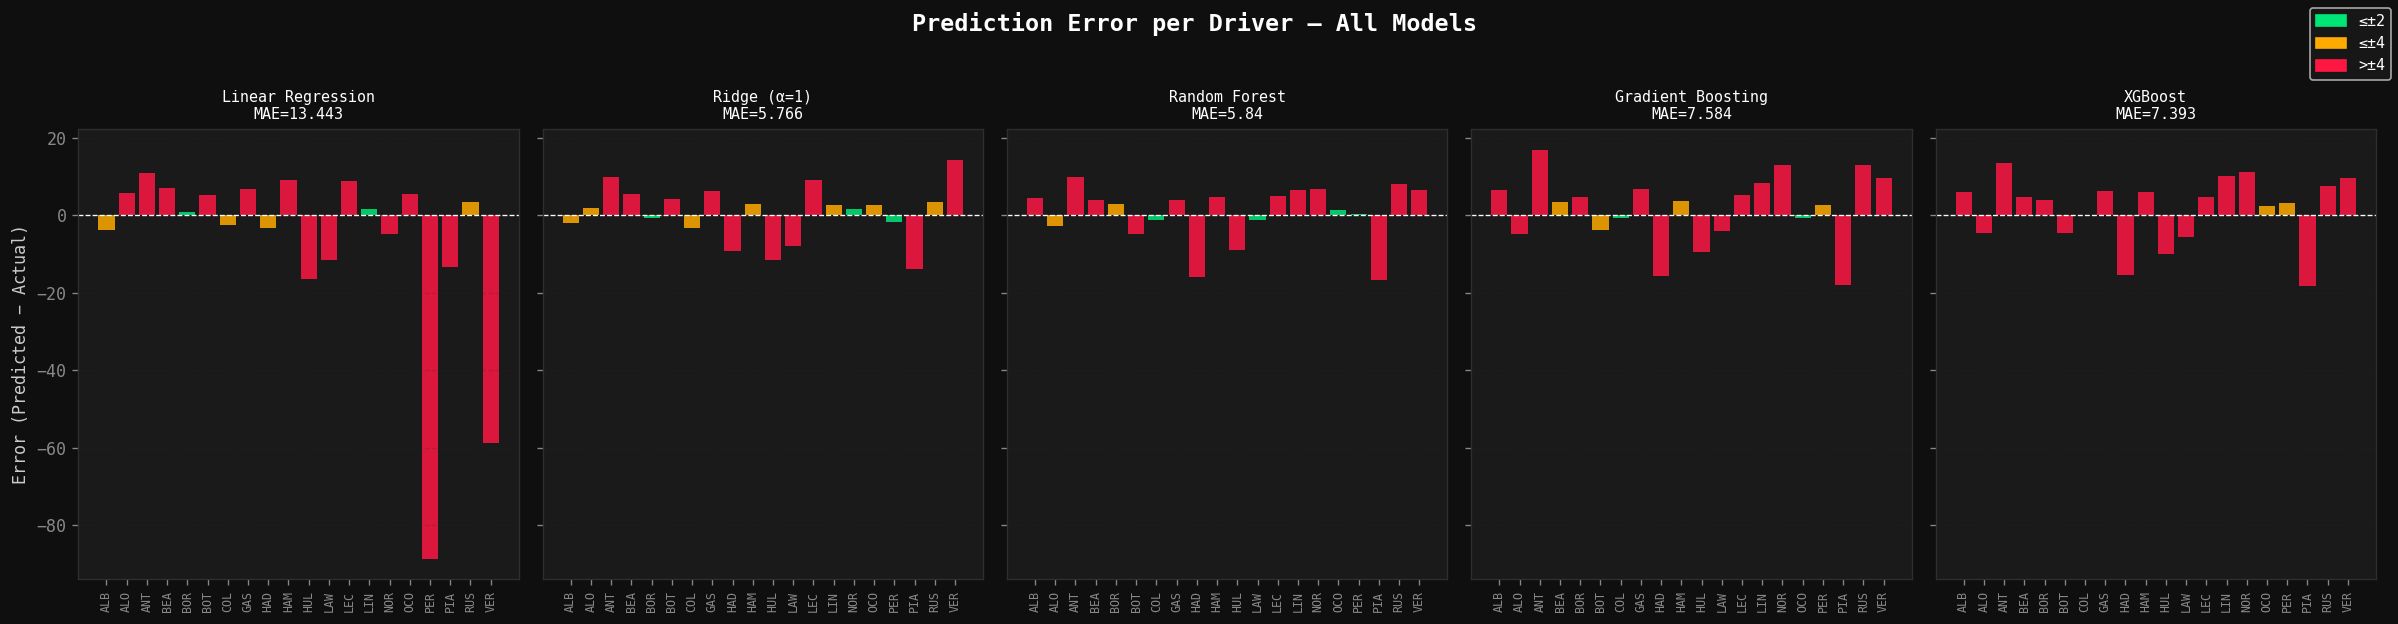

In [25]:
# ── Error distribution per model ─────────────────────────────
fig, axes = plt.subplots(1, len(models), figsize=(4*len(models), 5), sharey=True)
fig.patch.set_facecolor('#0f0f0f')

for ax, (name, preds) in zip(axes, all_preds.items()):
    errors = preds - y.values
    colors = ['#00e676' if abs(e)<=2 else '#ffaa00' if abs(e)<=4 else '#ff1744'
              for e in errors]
    ax.bar(range(len(errors)), errors, color=colors, alpha=0.85)
    ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(len(errors)))
    ax.set_xticklabels(df_ml['Driver'].values, rotation=90, fontsize=7)
    ax.set_title(f'{name}\nMAE={results[name]["MAE"]}',
                 color='white', fontsize=9, pad=6)
    ax.grid(axis='y', alpha=0.2)

axes[0].set_ylabel('Error (Predicted − Actual)')
fig.legend(handles=[
    mpatches.Patch(color='#00e676', label='≤±2'),
    mpatches.Patch(color='#ffaa00', label='≤±4'),
    mpatches.Patch(color='#ff1744', label='>±4'),
], loc='upper right', facecolor='#1a1a1a', labelcolor='white', fontsize=9)

plt.suptitle('Prediction Error per Driver — All Models',
             color='white', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout(); savefig('05_error_per_driver.png'); plt.show()


## 7. 🎯 Feature Importance

  💾 ./figures_ml/06_feature_importance.png


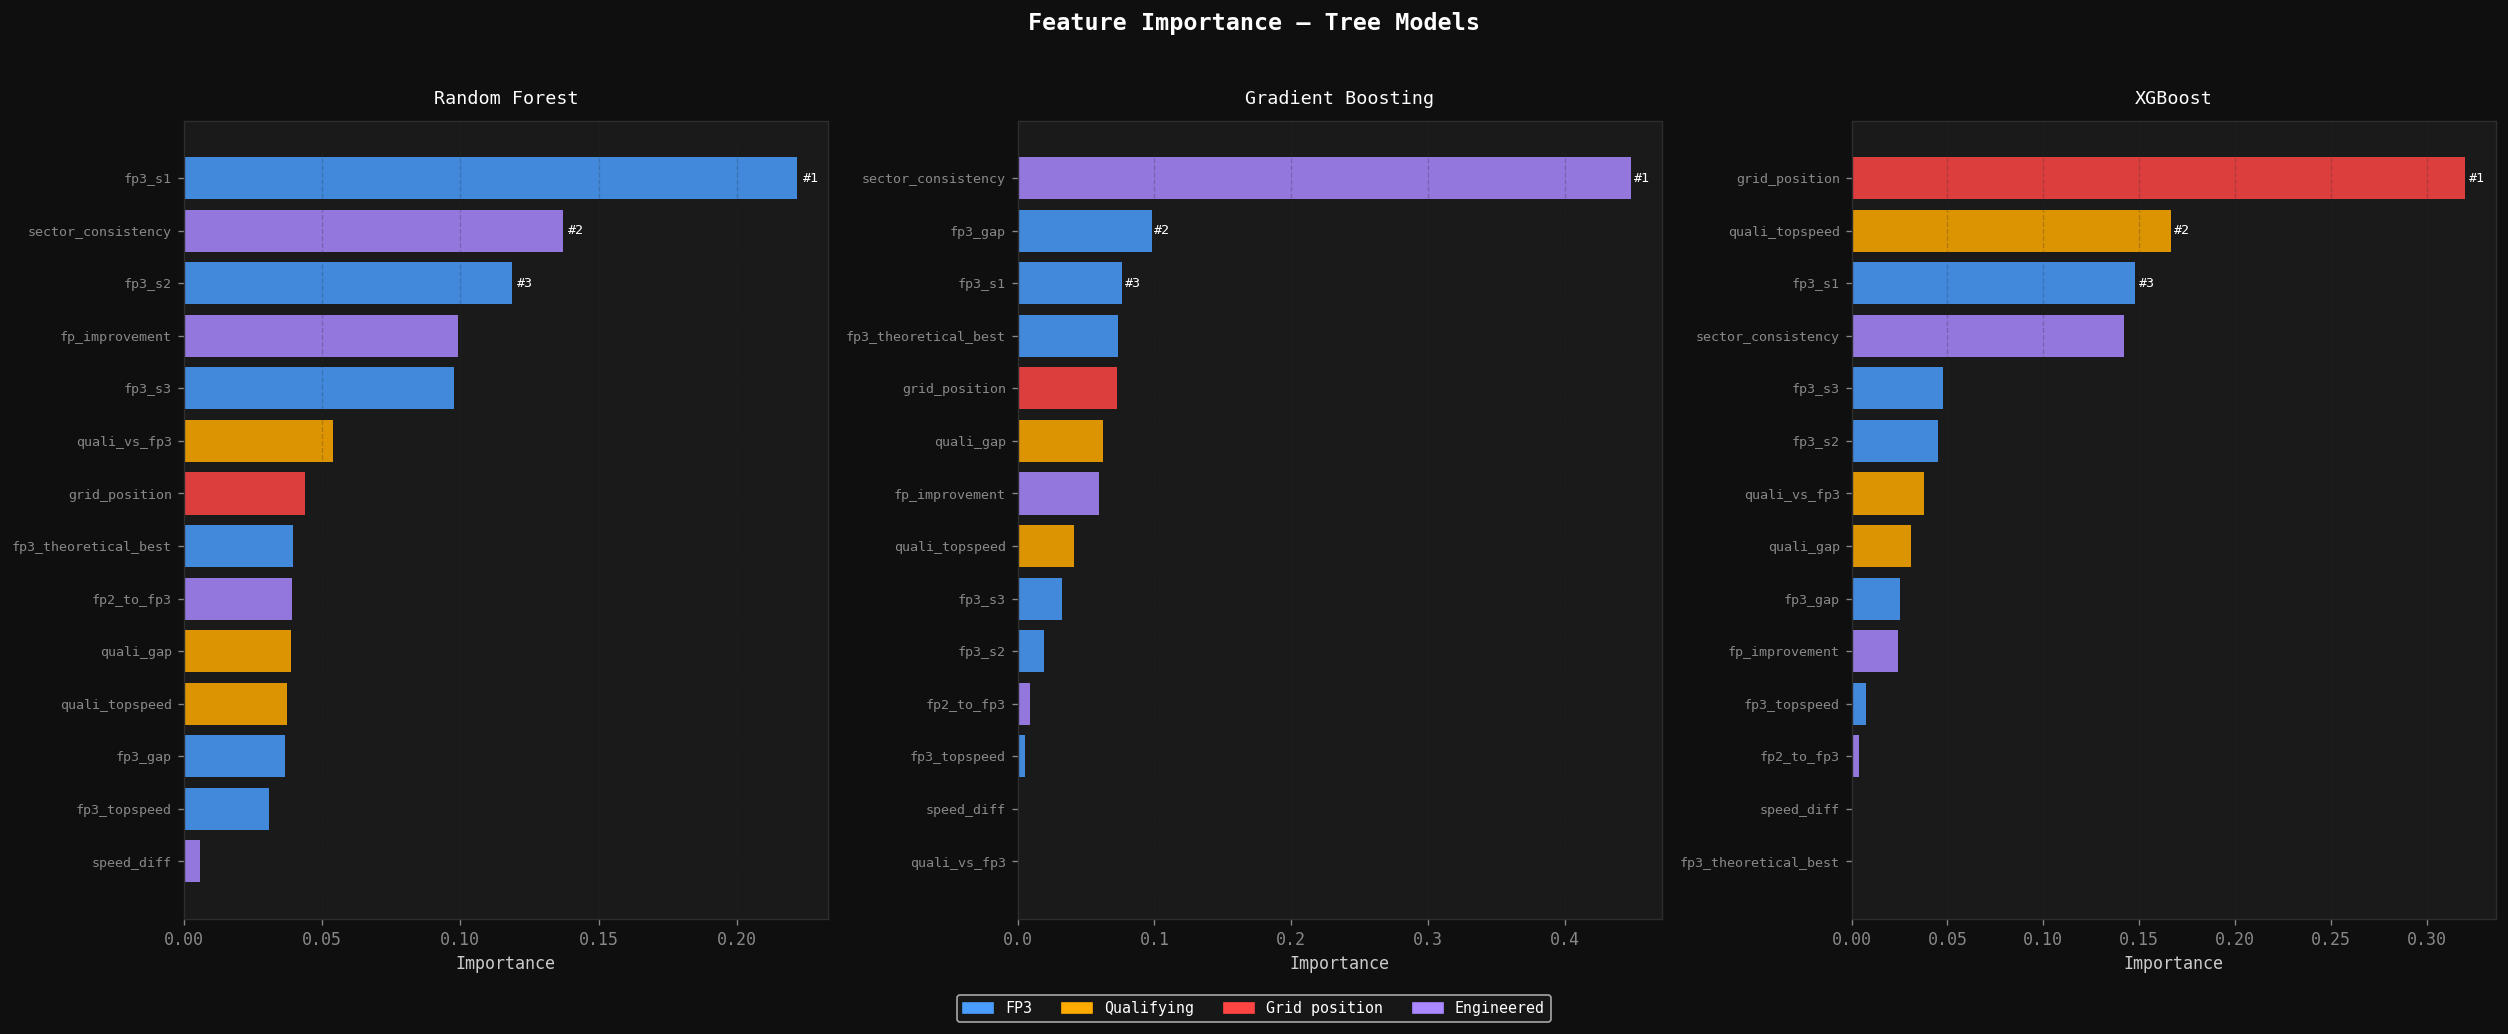

In [26]:
# ── Tree model importance ─────────────────────────────────────
tree_models = {k:v for k,v in models.items() if hasattr(v,'feature_importances_')}

def feat_color(f):
    if f.startswith('fp3'):    return '#4a9eff'
    if f.startswith('quali'):  return '#ffaa00'
    if f == 'grid_position':   return '#ff4444'
    return '#aa88ff'

fig, axes = plt.subplots(1, len(tree_models), figsize=(7*len(tree_models), 8))
fig.patch.set_facecolor('#0f0f0f')
if len(tree_models)==1: axes=[axes]

for ax, (name, model) in zip(axes, tree_models.items()):
    imp = pd.Series(model.feature_importances_, index=MODEL_FEATURES).sort_values(ascending=True)
    ax.barh(range(len(imp)), imp.values,
            color=[feat_color(f) for f in imp.index], alpha=0.85)
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp.index, fontsize=8)
    ax.set_title(name, color='white', fontsize=11, pad=10)
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.25)
    for rank, (feat, val) in enumerate(imp.sort_values(ascending=False).head(3).items()):
        idx = list(imp.index).index(feat)
        ax.text(val+0.002, idx, f'#{rank+1}', va='center', fontsize=8, color='white')

fig.legend(handles=[
    mpatches.Patch(color='#4a9eff', label='FP3'),
    mpatches.Patch(color='#ffaa00', label='Qualifying'),
    mpatches.Patch(color='#ff4444', label='Grid position'),
    mpatches.Patch(color='#aa88ff', label='Engineered'),
], loc='lower center', ncol=4, facecolor='#1a1a1a', labelcolor='white',
   fontsize=9, bbox_to_anchor=(0.5,-0.04))

plt.suptitle('Feature Importance — Tree Models',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); savefig('06_feature_importance.png'); plt.show()


  💾 ./figures_ml/07_ridge_coefficients.png


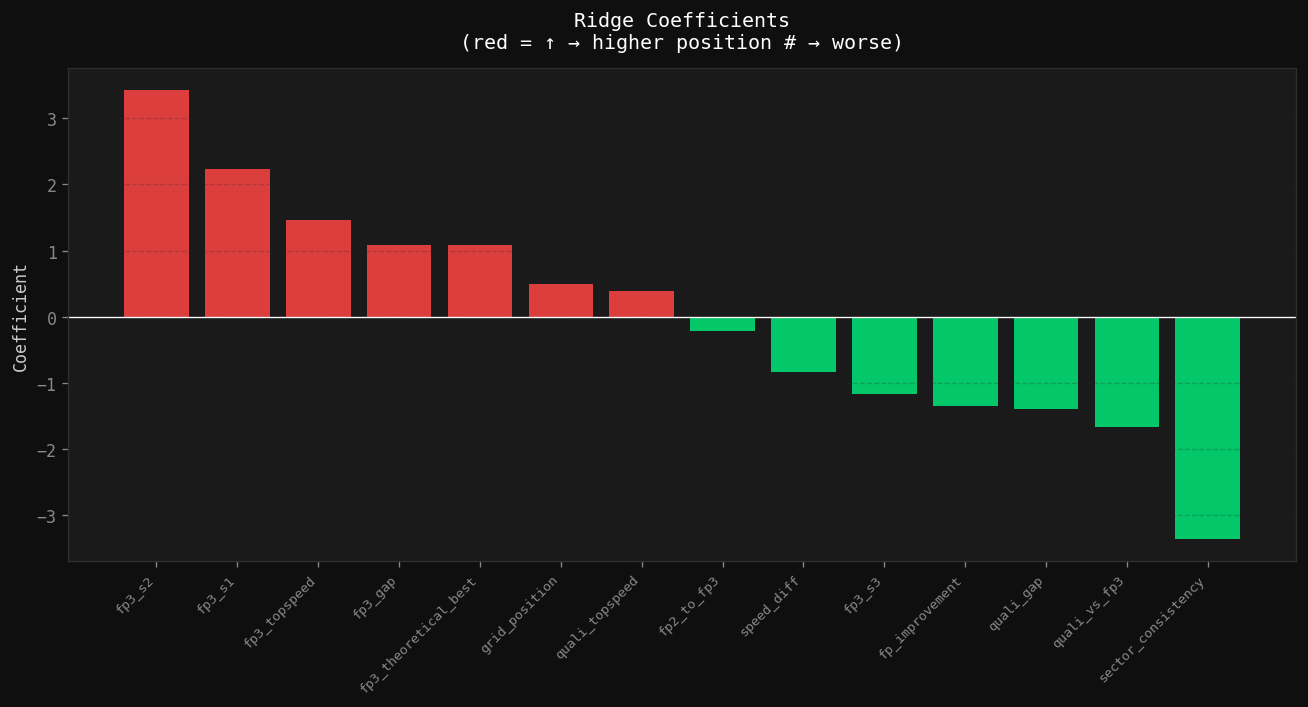

In [27]:
# ── Ridge coefficients ────────────────────────────────────────
ridge = models.get('Ridge (α=1)', LinearRegression())
ridge.fit(X_scaled, y)
coef = pd.Series(ridge.coef_, index=MODEL_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0f0f0f')
bar_c = ['#ff4444' if v>0 else '#00e676' for v in coef.values]
ax.bar(range(len(coef)), coef.values, color=bar_c, alpha=0.85)
ax.set_xticks(range(len(coef)))
ax.set_xticklabels(coef.index, rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='white', linewidth=0.8)
ax.set_title('Ridge Coefficients\n(red = ↑ → higher position # → worse)',
             color='white', pad=12)
ax.set_ylabel('Coefficient')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout(); savefig('07_ridge_coefficients.png'); plt.show()


## 8. 🏁 Actual vs Predicted

  💾 ./figures_ml/08_actual_vs_predicted.png


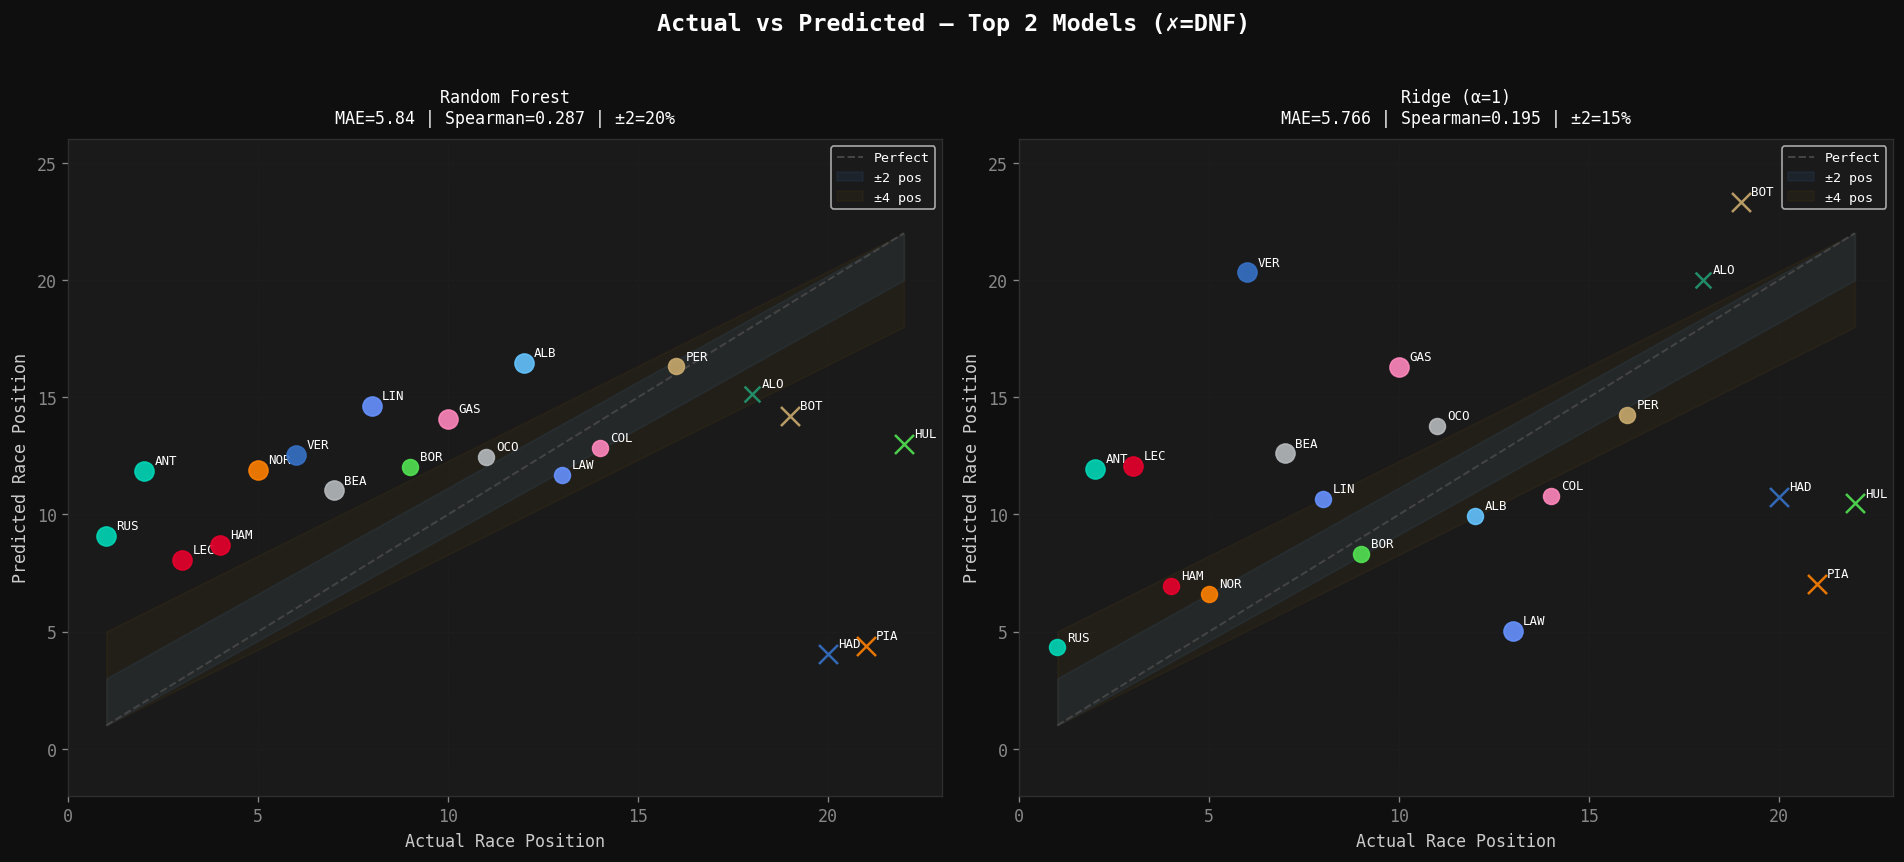

In [28]:
# ── Top 2 models ─────────────────────────────────────────────
top2 = pd.DataFrame(results).T['Spearman'].astype(float).nlargest(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0f0f0f')

for ax, name in zip(axes, top2):
    preds  = all_preds[name]
    errors = np.abs(preds - y.values)

    for i, driver in enumerate(df_ml['Driver'].values):
        c = driver_color.get(driver,'#888888')
        m = 'x' if df_ml['dnf'].iloc[i] else 'o'
        ax.scatter(y.values[i], preds[i], color=c, s=130 if errors[i]>4 else 90,
                   marker=m, alpha=0.9, zorder=5)
        ax.annotate(driver, (y.values[i], preds[i]),
                    textcoords='offset points', xytext=(6,4),
                    fontsize=7.5, color='white')

    ax.plot([1,22],[1,22],'--',color='#444',linewidth=1.2,label='Perfect')
    ax.fill_between([1,22],[max(1,l-2) for l in [1,22]],
                           [min(22,l+2) for l in [1,22]],
                    alpha=0.07, color='#4a9eff', label='±2 pos')
    ax.fill_between([1,22],[max(1,l-4) for l in [1,22]],
                           [min(22,l+4) for l in [1,22]],
                    alpha=0.04, color='#ffaa00', label='±4 pos')

    r = results[name]
    ax.set_title(f'{name}\nMAE={r["MAE"]} | Spearman={r["Spearman"]} | ±2={r["Within±2"]}',
                 color='white', fontsize=10, pad=10)
    ax.set_xlabel('Actual Race Position')
    ax.set_ylabel('Predicted Race Position')
    ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
    ax.grid(alpha=0.2)
    ax.set_xlim(0,23); ax.set_ylim(-2,26)

plt.suptitle('Actual vs Predicted — Top 2 Models (✗=DNF)',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); savefig('08_actual_vs_predicted.png'); plt.show()


  💾 ./figures_ml/09_prediction_error.png


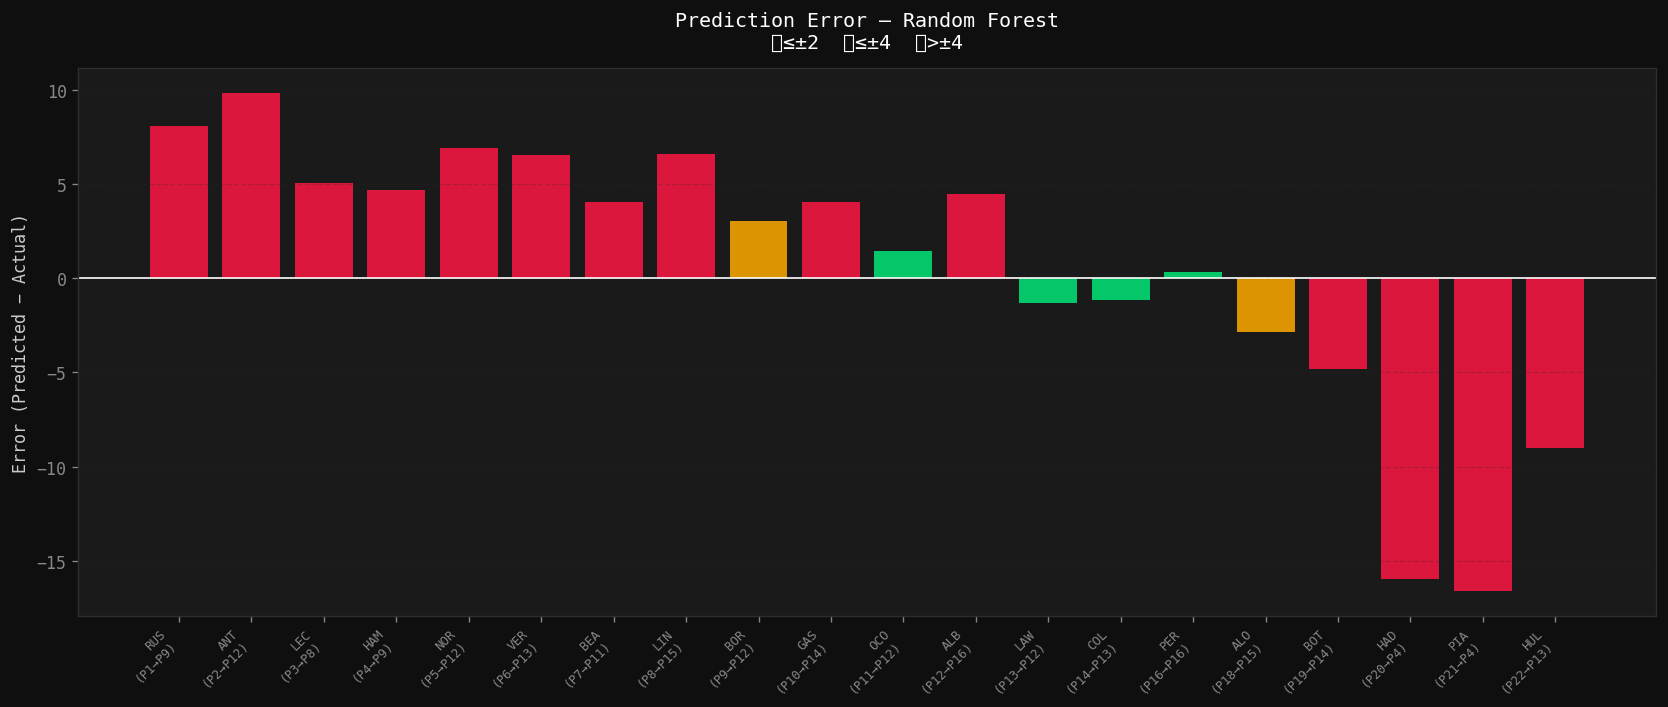


📋 Full prediction table:
Driver            Team  Actual  Predicted  Error
   RUS        Mercedes       1        9.1   8.07
   ANT        Mercedes       2       11.8   9.84
   LEC         Ferrari       3        8.1   5.07
   HAM         Ferrari       4        8.7   4.70
   NOR         McLaren       5       11.9   6.90
   VER Red Bull Racing       6       12.6   6.56
   BEA    Haas F1 Team       7       11.0   4.03
   LIN    Racing Bulls       8       14.6   6.62
   BOR            Audi       9       12.0   3.02
   GAS          Alpine      10       14.1   4.07
   OCO    Haas F1 Team      11       12.5   1.45
   ALB        Williams      12       16.5   4.48
   LAW    Racing Bulls      13       11.7  -1.31
   COL          Alpine      14       12.8  -1.16
   PER        Cadillac      16       16.3   0.32
   ALO    Aston Martin      18       15.2  -2.85
   BOT        Cadillac      19       14.2  -4.80
   HAD Red Bull Racing      20        4.0 -15.97
   PIA         McLaren      21        4.4 -

In [29]:
# ── Error barchart — best model ───────────────────────────────
best_preds = all_preds[best_name]
error_df = pd.DataFrame({
    'Driver'   : df_ml['Driver'].values,
    'Team'     : df_ml['Team'].values,
    'Actual'   : y.values,
    'Predicted': best_preds.round(1),
    'Error'    : (best_preds - y.values).round(2),
    'AbsError' : np.abs(best_preds - y.values).round(2),
}).sort_values('Actual').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f0f0f')
bar_c = ['#00e676' if abs(e)<=2 else '#ffaa00' if abs(e)<=4 else '#ff1744'
         for e in error_df['Error']]
ax.bar(range(len(error_df)), error_df['Error'], color=bar_c, alpha=0.85)
ax.axhline(0, color='white', linewidth=1)
ax.set_xticks(range(len(error_df)))
ax.set_xticklabels(
    [f"{r.Driver}\n(P{int(r.Actual)}→P{r.Predicted:.0f})" for _,r in error_df.iterrows()],
    fontsize=7.5, rotation=45, ha='right')
ax.set_ylabel('Error (Predicted − Actual)')
ax.set_title(f'Prediction Error — {best_name}\n🟢≤±2  🟡≤±4  🔴>±4',
             color='white', pad=12)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout(); savefig('09_prediction_error.png'); plt.show()

print('\n📋 Full prediction table:')
print(error_df[['Driver','Team','Actual','Predicted','Error']].to_string(index=False))


## 9. 💡 Summary & Export

In [30]:
# ── 9.1 Text summary ─────────────────────────────────────────
print('=' * 65)
print('  🏆  F1 2026 AUSTRALIAN GP — ML SUMMARY')
print('=' * 65)
print()
print('📊 LOO-CV Results:')
print(pd.DataFrame(results).T.to_string())

b = results[best_name]
print(f'\n🥇 Best: {best_name}')
print(f'   MAE       : {b["MAE"]} positions')
print(f'   Spearman  : {b["Spearman"]}')
print(f'   Within ±2 : {b["Within±2"]}')
print(f'   Within ±3 : {b["Within±3"]}')

# Top features RF
if 'Random Forest' in models:
    rf_imp = pd.Series(models['Random Forest'].feature_importances_,
                       index=MODEL_FEATURES).sort_values(ascending=False)
    print(f'\n🔑 Top 5 Features (RF):')
    for i,(feat,val) in enumerate(rf_imp.head(5).items(),1):
        print(f'   {i}. {feat:30s}: {val:.3f}')

# Correlations
print(f'\n📈 Key Correlations with race_pos:')
for feat in ['quali_gap','grid_position','fp3_gap']:
    r_val = df[[feat,'race_pos']].dropna().corr().iloc[0,1]
    print(f'   {feat:25s}: r = {r_val:+.3f}')

# Surprises
print(f'\n⚠️  Biggest Surprises:')
for _, row in error_df.sort_values('AbsError', ascending=False).head(4).iterrows():
    direction = 'better' if row['Error']<0 else 'worse'
    print(f'   {row.Driver:5s} ({row.Team}): '
          f'pred P{row.Predicted:.0f} → actual P{int(row.Actual)} '
          f'({row.AbsError:.1f} pos {direction})')


  🏆  F1 2026 AUSTRALIAN GP — ML SUMMARY

📊 LOO-CV Results:
                      MAE      R² Spearman p-value Within±2 Within±3
Linear Regression  13.443 -13.872    0.132  0.5781      10%      15%
Ridge (α=1)         5.766  -0.207    0.195  0.4088      15%      40%
Random Forest        5.84  -0.257    0.287  0.2195      20%      25%
Gradient Boosting   7.584  -0.996   -0.271  0.2484      10%      15%
XGBoost             7.393  -0.778   -0.104  0.6633       5%      10%

🥇 Best: Random Forest
   MAE       : 5.84 positions
   Spearman  : 0.287
   Within ±2 : 20%
   Within ±3 : 25%

🔑 Top 5 Features (RF):
   1. fp3_s1                        : 0.222
   2. sector_consistency            : 0.137
   3. fp3_s2                        : 0.119
   4. fp_improvement                : 0.099
   5. fp3_s3                        : 0.098

📈 Key Correlations with race_pos:
   quali_gap                : r = -0.044
   grid_position            : r = +0.366
   fp3_gap                  : r = +0.543

⚠️  Biggest 

  💾 ./figures_ml/10_ml_dashboard.png


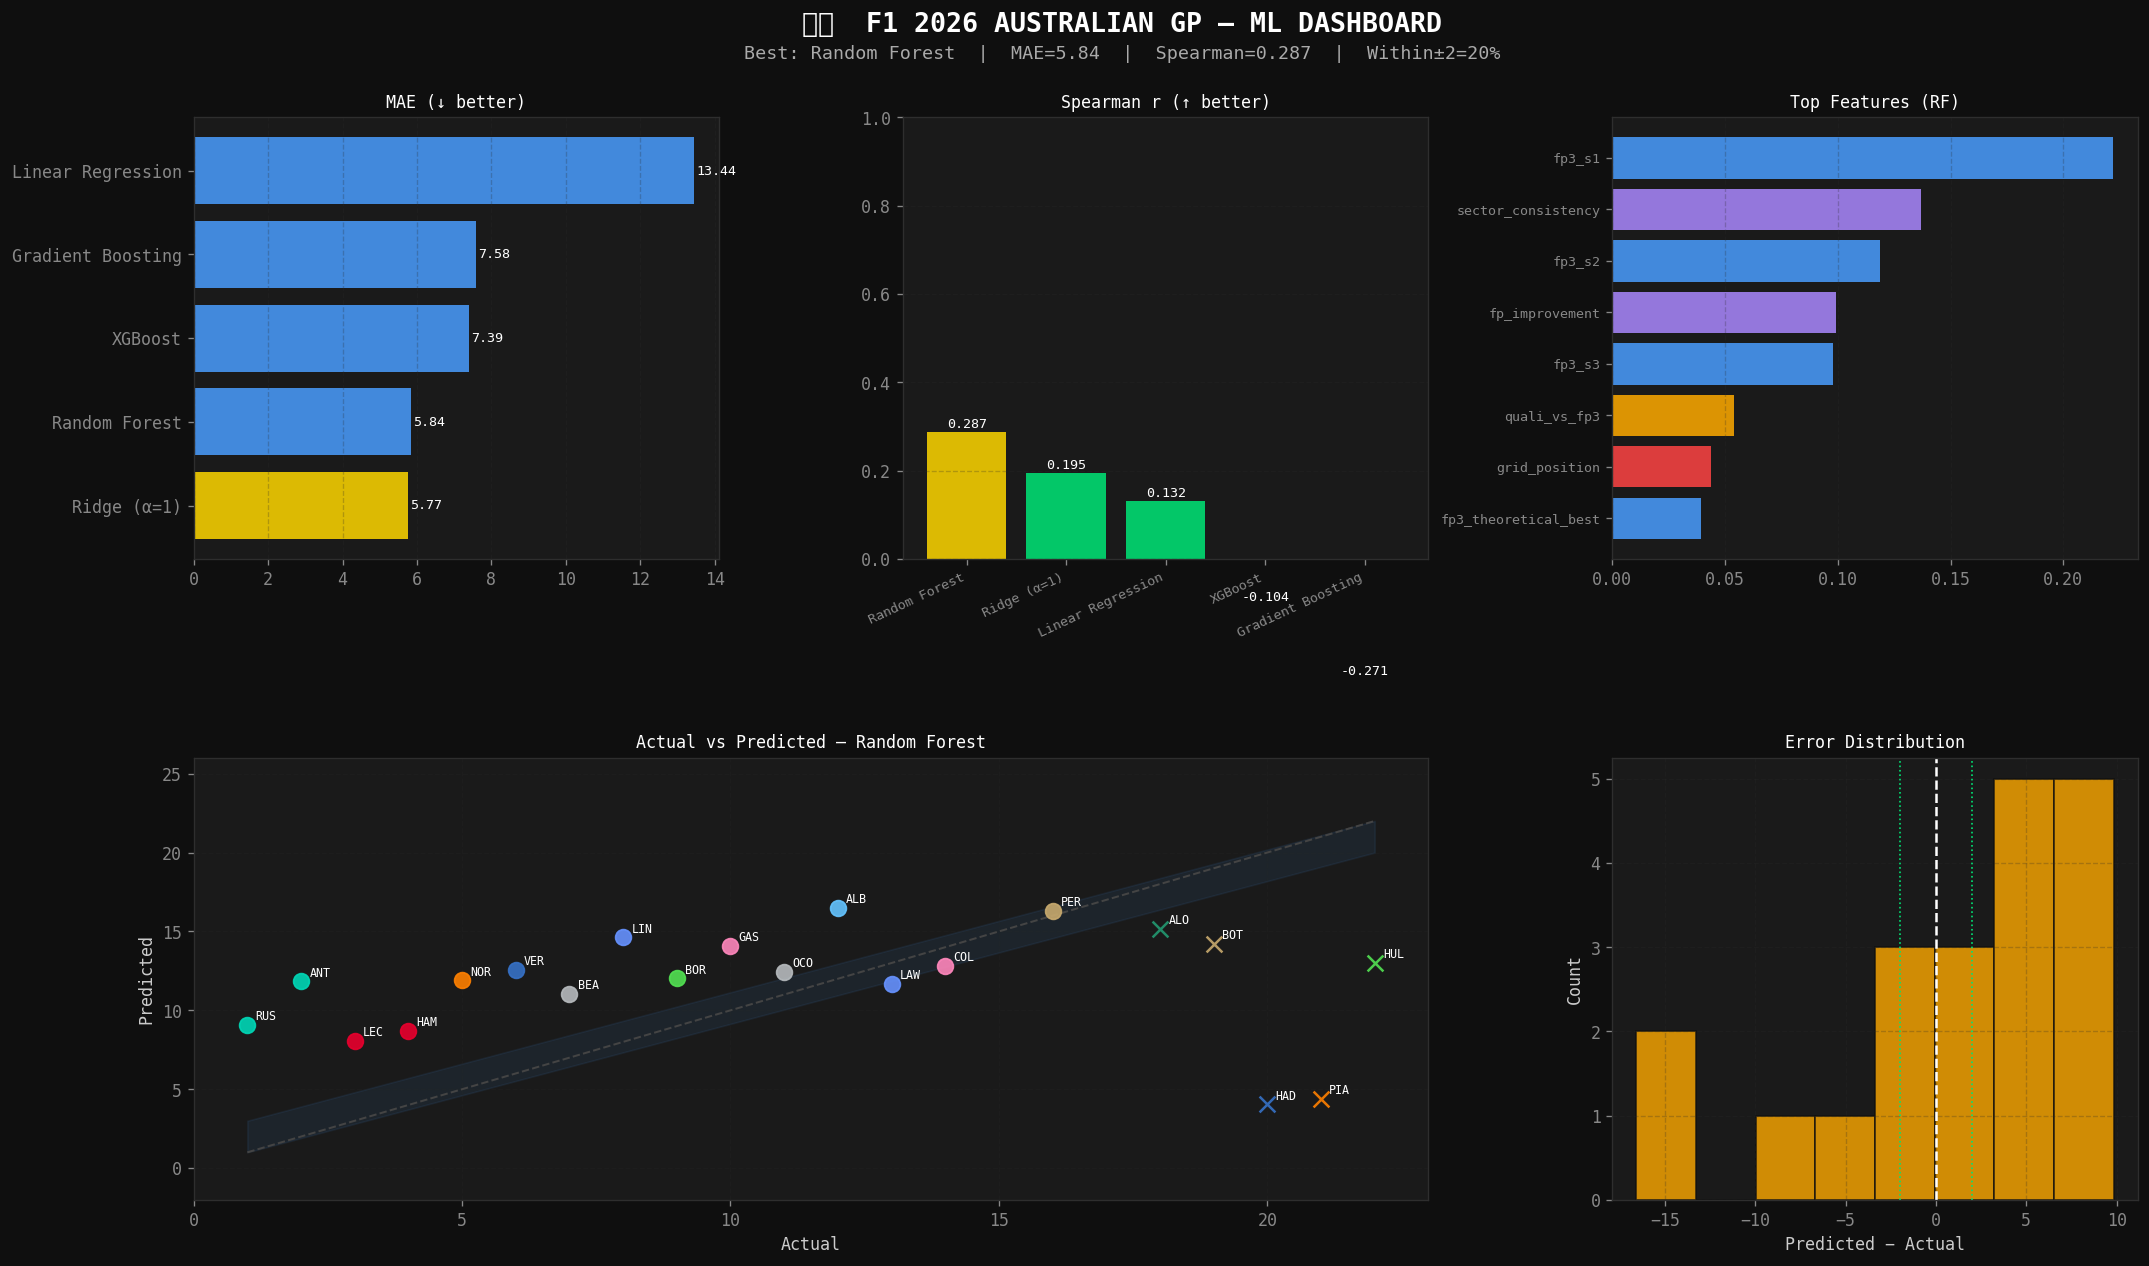

In [31]:
# ── 9.2 Dashboard ────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#0f0f0f')
fig.text(0.5, 0.98, '🏎️  F1 2026 AUSTRALIAN GP — ML DASHBOARD',
         ha='center', va='top', color='white', fontsize=16, fontweight='bold')
b = results[best_name]
fig.text(0.5, 0.955,
         f'Best: {best_name}  |  MAE={b["MAE"]}  |  '
         f'Spearman={b["Spearman"]}  |  Within±2={b["Within±2"]}',
         ha='center', va='top', color='#aaaaaa', fontsize=11)

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35,
                      top=0.90, bottom=0.08, left=0.07, right=0.97)

# [0,0] MAE
ax0 = fig.add_subplot(gs[0,0])
maes = pd.DataFrame(results).T['MAE'].astype(float).sort_values()
ax0.barh(maes.index, maes.values,
         color=['#ffd700' if m==maes.idxmin() else '#4a9eff' for m in maes.index],
         alpha=0.85)
ax0.set_title('MAE (↓ better)', color='white', fontsize=10)
ax0.grid(axis='x', alpha=0.25)
for i,v in enumerate(maes.values):
    ax0.text(v+0.05, i, f'{v:.2f}', va='center', fontsize=8, color='white')

# [0,1] Spearman
ax1 = fig.add_subplot(gs[0,1])
spears = pd.DataFrame(results).T['Spearman'].astype(float).sort_values(ascending=False)
ax1.bar(range(len(spears)), spears.values,
        color=['#ffd700' if m==spears.idxmax() else '#00e676' for m in spears.index],
        alpha=0.85)
ax1.set_xticks(range(len(spears)))
ax1.set_xticklabels(spears.index, rotation=25, ha='right', fontsize=8)
ax1.set_title('Spearman r (↑ better)', color='white', fontsize=10)
ax1.set_ylim(0,1); ax1.grid(axis='y', alpha=0.25)
for i,v in enumerate(spears.values):
    ax1.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=8, color='white')

# [0,2] RF feature importance top 8
ax2 = fig.add_subplot(gs[0,2])
if 'Random Forest' in models:
    rf_top = rf_imp.head(8).sort_values()
    ax2.barh(range(len(rf_top)), rf_top.values,
             color=[feat_color(f) for f in rf_top.index], alpha=0.85)
    ax2.set_yticks(range(len(rf_top)))
    ax2.set_yticklabels(rf_top.index, fontsize=8)
    ax2.set_title('Top Features (RF)', color='white', fontsize=10)
    ax2.grid(axis='x', alpha=0.25)

# [1,0:2] Actual vs Predicted
ax3 = fig.add_subplot(gs[1,0:2])
preds = all_preds[best_name]
for i, driver in enumerate(df_ml['Driver'].values):
    c = driver_color.get(driver,'#888888')
    m = 'x' if df_ml['dnf'].iloc[i] else 'o'
    ax3.scatter(y.values[i], preds[i], color=c, s=90, marker=m, alpha=0.9, zorder=5)
    ax3.annotate(driver, (y.values[i], preds[i]),
                 textcoords='offset points', xytext=(5,3), fontsize=7, color='white')
ax3.plot([1,22],[1,22],'--',color='#444',linewidth=1.2)
ax3.fill_between([1,22],[max(1,l-2) for l in [1,22]],[min(22,l+2) for l in [1,22]],
                 alpha=0.08, color='#4a9eff')
ax3.set_title(f'Actual vs Predicted — {best_name}', color='white', fontsize=10)
ax3.set_xlabel('Actual'); ax3.set_ylabel('Predicted')
ax3.grid(alpha=0.2); ax3.set_xlim(0,23); ax3.set_ylim(-2,26)

# [1,2] Error histogram
ax4 = fig.add_subplot(gs[1,2])
errs = preds - y.values
ax4.hist(errs, bins=8, color='#ffaa00', alpha=0.8, edgecolor='#0f0f0f')
ax4.axvline(0, color='white', linewidth=1.5, linestyle='--')
ax4.axvline( 2, color='#00e676', linewidth=1, linestyle=':')
ax4.axvline(-2, color='#00e676', linewidth=1, linestyle=':')
ax4.set_title('Error Distribution', color='white', fontsize=10)
ax4.set_xlabel('Predicted − Actual'); ax4.set_ylabel('Count')
ax4.grid(alpha=0.25)

savefig('10_ml_dashboard.png'); plt.show()


In [32]:
# ── 9.3 Export predictions ────────────────────────────────────
os.makedirs('processed', exist_ok=True)

pred_export = df_ml[['Driver','Team','grid_position','race_pos']].copy()
pred_export.columns = ['Driver','Team','Grid','Actual_Pos']

for name, preds in all_preds.items():
    col = name.replace(' ','_').replace('(','').replace(')','').replace('=','')
    pred_export[f'Pred_{col}'] = preds.round(1)
    pred_export[f'Err_{col}']  = (preds - y.values).round(2)

pred_export.to_csv('processed/predictions.csv', index=False)
print('✅ Saved: processed/predictions.csv')
print()
print(pred_export[['Driver','Team','Grid','Actual_Pos'] +
                  [c for c in pred_export.columns if c.startswith('Pred_')]].to_string(index=False))
print()
print(f'📁 All figures saved to ./{FIG_DIR}/:')
import glob
for f in sorted(glob.glob(f'{FIG_DIR}/*.png')):
    print(f'   {f}')


✅ Saved: processed/predictions.csv

Driver            Team  Grid  Actual_Pos  Pred_Linear_Regression  Pred_Ridge_α1  Pred_Random_Forest  Pred_Gradient_Boosting  Pred_XGBoost
   ALB        Williams  15.0          12                     8.1            9.9                16.5                    18.6          18.1
   ALO    Aston Martin  17.0          18                    23.8           20.0                15.2                    13.1          13.5
   ANT        Mercedes   2.0           2                    12.9           12.0                11.8                    18.9          15.5
   BEA    Haas F1 Team  12.0           7                    14.1           12.6                11.0                    10.5          11.6
   BOR            Audi  10.0           9                     9.8            8.3                12.0                    13.9          13.1
   BOT        Cadillac  19.0          19                    24.2           23.3                14.2                    15.1          14.